# Predicting the Future Across Cultures: simulated analysis

This notebook reads the simulated PsyNet exports for English, Italian, and Hebrew and checks whether the injected bot profiles create visible condition-by-language patterns. The simulated data are workflow evidence, not human behavioral results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.dpi"] = 45
BASE = Path("..").resolve()
LOCALES = ["en", "it", "he"]
CATEGORY_ORDER = ["life_spans", "marriages", "movie_run_times", "poem_lengths", "waiting_times"]
CATEGORY_LABELS = {
    "life_spans": "Life spans",
    "marriages": "Marriages",
    "movie_run_times": "Movie run times",
    "poem_lengths": "Poem lengths",
    "waiting_times": "Waiting times",
}
frames = []
for locale in LOCALES:
    path = BASE / "simulated_exports" / locale / "regular" / "data" / "PredictionTrial.csv"
    df = pd.read_csv(path)
    df["export_locale"] = locale
    frames.append(df)

trials = pd.concat(frames, ignore_index=True)
trials = trials[trials["prediction_is_finite"] == True].copy()
trials[["export_locale", "displayed_locale", "category", "t_past", "prediction", "validation_failures"]].head()

,export_locale,displayed_locale,category,t_past,prediction,validation_failures
0,en,en,waiting_times,7,20.0,0
1,en,en,marriages,7,21.8,0
2,en,en,poem_lengths,2,9.3,0
3,en,en,life_spans,39,70.2,0
4,en,en,movie_run_times,80,98.8,0


In [2]:
counts = (
    trials.groupby(["export_locale", "displayed_locale", "category"], as_index=False)
    .agg(n_trials=("id", "count"), min_prediction=("prediction", "min"), min_t_past=("t_past", "min"), validation_failures=("validation_failures", "sum"))
)
counts

,export_locale,displayed_locale,category,n_trials,min_prediction,min_t_past,validation_failures
0,en,en,life_spans,18,60.9,18,0
1,en,en,marriages,18,16.8,1,0
2,en,en,movie_run_times,18,58.3,30,0
3,en,en,poem_lengths,18,8.0,2,0
4,en,en,waiting_times,18,8.0,1,0
5,he,he,life_spans,18,66.0,18,0
6,he,he,marriages,18,16.8,1,0
7,he,he,movie_run_times,18,62.1,30,0
8,he,he,poem_lengths,18,5.3,2,0
9,he,he,waiting_times,18,8.0,1,0


In [3]:
assert set(trials["export_locale"]) == set(LOCALES)
assert (trials["export_locale"] == trials["displayed_locale"]).all()
assert set(trials["category"]) == set(CATEGORY_ORDER)
assert (trials["prediction"] >= trials["t_past"]).all()
assert counts["n_trials"].min() > 0
print(f"Validated {len(trials)} finite simulated prediction trials across {len(LOCALES)} locales.")

Validated 270 finite simulated prediction trials across 3 locales.


In [4]:
summary = (
    trials.groupby(["category", "displayed_locale", "t_past"], as_index=False)
    .agg(median_prediction=("prediction", "median"), mean_prediction=("prediction", "mean"), n=("prediction", "size"))
)
summary.head(15)

,category,displayed_locale,t_past,median_prediction,mean_prediction,n
0,life_spans,en,18,63.95,63.350000,4
1,life_spans,en,39,70.05,70.025000,4
2,life_spans,en,61,75.10,76.600000,3
3,life_spans,en,83,85.10,84.925000,4
4,life_spans,en,96,96.00,96.000000,3
5,life_spans,he,18,67.55,67.300000,4
6,life_spans,he,39,73.40,73.650000,4
7,life_spans,he,61,83.70,83.333333,3
8,life_spans,he,83,92.20,91.300000,3
9,life_spans,he,96,96.00,96.775000,4


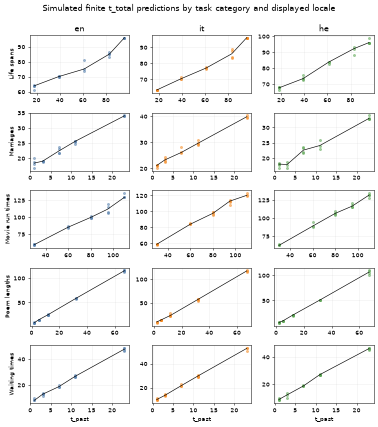

In [5]:
fig, axes = plt.subplots(len(CATEGORY_ORDER), len(LOCALES), figsize=(8.5, 9.5), sharex=False, sharey=False)
colors = {"en": "#4c78a8", "it": "#f58518", "he": "#54a24b"}
for row, category in enumerate(CATEGORY_ORDER):
    for col, locale in enumerate(LOCALES):
        ax = axes[row, col]
        subset = trials[(trials["category"] == category) & (trials["displayed_locale"] == locale)]
        ax.scatter(subset["t_past"], subset["prediction"], s=12, alpha=0.55, color=colors[locale])
        med = summary[(summary["category"] == category) & (summary["displayed_locale"] == locale)]
        ax.plot(med["t_past"], med["median_prediction"], color="black", linewidth=1)
        if row == 0:
            ax.set_title(locale)
        if col == 0:
            ax.set_ylabel(CATEGORY_LABELS[category])
        if row == len(CATEGORY_ORDER) - 1:
            ax.set_xlabel("t_past")
        ax.grid(alpha=0.2)
fig.suptitle("Simulated finite t_total predictions by task category and displayed locale", y=0.995)
fig.tight_layout()
plt.show()

## Interpretation

The export contains complete finite predictions for all five categories in all three displayed locales. The plotted differences are expected because the bot profiles intentionally add modest locale-specific offsets/slopes for testing. These simulated patterns demonstrate that the experiment and analysis pipeline can represent language-by-condition variation; they are not evidence of real cross-cultural differences.